In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             f1_score, roc_curve)
from sklearn.model_selection import GridSearchCV 
from sklearn.feature_selection import RFECV
import joblib

In [2]:
df_raw = pd.read_csv("data/train.csv")
df = df_raw.copy()
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
df.rename(columns={
    "id"                  : "ID_Client",
    "Gender"              : "Sexe",
    "Age"                 : "Age",
    "Driving_License"     : "Permis_Conduire",
    "Region_Code"         : "Code_Region",
    "Previously_Insured"  : "Assure_Avant",
    "Vehicle_Age"         : "Age_Vehicule",
    "Vehicle_Damage"      : "Dommages_Vehicule",
    "Annual_Premium"      : "Prime_Annuelle",
    "Policy_Sales_Channel": "Canal_Vente",
    "Vintage"             : "Anciennete_Client",
    "Response"            : "Souscription"
}, inplace=True)

print("Colonnes renommées :")
print(df.columns.tolist())

Colonnes renommées :
['ID_Client', 'Sexe', 'Age', 'Permis_Conduire', 'Code_Region', 'Assure_Avant', 'Age_Vehicule', 'Dommages_Vehicule', 'Prime_Annuelle', 'Canal_Vente', 'Anciennete_Client', 'Souscription']


### Exploratory Data Analysis (EDA)

In [4]:
print(f"Shape : {df.shape}")
print(f"\nTypes :")
print(df.dtypes)
print(f"\nAperçu statistique :")
df.describe().round(2)

Shape : (381109, 12)

Types :
ID_Client              int64
Sexe                  object
Age                    int64
Permis_Conduire        int64
Code_Region          float64
Assure_Avant           int64
Age_Vehicule          object
Dommages_Vehicule     object
Prime_Annuelle       float64
Canal_Vente          float64
Anciennete_Client      int64
Souscription           int64
dtype: object

Aperçu statistique :


,ID_Client,Age,Permis_Conduire,Code_Region,Assure_Avant,Prime_Annuelle,Canal_Vente,Anciennete_Client,Souscription
count,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00
mean,190555.00,38.82,1.00,26.39,0.46,30564.39,112.03,154.35,0.12
std,110016.84,15.51,0.05,13.23,0.50,17213.16,54.20,83.67,0.33
min,1.00,20.00,0.00,0.00,0.00,2630.00,1.00,10.00,0.00
25%,95278.00,25.00,1.00,15.00,0.00,24405.00,29.00,82.00,0.00
50%,190555.00,36.00,1.00,28.00,0.00,31669.00,133.00,154.00,0.00
75%,285832.00,49.00,1.00,35.00,1.00,39400.00,152.00,227.00,0.00
max,381109.00,85.00,1.00,52.00,1.00,540165.00,163.00,299.00,1.00


In [5]:
# Valeurs manquantes
nulls = df.isnull().sum()
print("Valeurs manquantes :")
print(nulls[nulls >= 0])

# Doublons
doublons = df.duplicated().sum()
print(f"\nNombre de doublons : {doublons}")
if doublons > 0:
    df.drop_duplicates(inplace=True)
    print("Doublons supprimés")

Valeurs manquantes :
ID_Client            0
Sexe                 0
Age                  0
Permis_Conduire      0
Code_Region          0
Assure_Avant         0
Age_Vehicule         0
Dommages_Vehicule    0
Prime_Annuelle       0
Canal_Vente          0
Anciennete_Client    0
Souscription         0
dtype: int64

Nombre de doublons : 0


In [6]:
# Classification des variables par cardinalité
cols_exclure = ["ID_Client"]

print("Cardinalité des variables :\n")
for col in df.columns:
    if col not in cols_exclure:
        n    = df[col].nunique()
        vals = sorted(df[col].dropna().unique())[:5]
        print(f"  {col:<25} {n:>6} valeurs uniques   ex: {vals}")

Cardinalité des variables :

  Sexe                           2 valeurs uniques   ex: ['Female', 'Male']
  Age                           66 valeurs uniques   ex: [np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  Permis_Conduire                2 valeurs uniques   ex: [np.int64(0), np.int64(1)]
  Code_Region                   53 valeurs uniques   ex: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Assure_Avant                   2 valeurs uniques   ex: [np.int64(0), np.int64(1)]
  Age_Vehicule                   3 valeurs uniques   ex: ['1-2 Year', '< 1 Year', '> 2 Years']
  Dommages_Vehicule              2 valeurs uniques   ex: ['No', 'Yes']
  Prime_Annuelle             48838 valeurs uniques   ex: [np.float64(2630.0), np.float64(6098.0), np.float64(7670.0), np.float64(8739.0), np.float64(9792.0)]
  Canal_Vente                  155 valeurs uniques   ex: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.flo

In [7]:
# Variables catégorielles texte (à encoder)
cols_cat_texte = ["Sexe", "Age_Vehicule", "Dommages_Vehicule"]
# Variables binaires (déjà 0/1 après encodage)
cols_binaires = ["Permis_Conduire", "Assure_Avant"]
# Variables continues VRAIMENT continues
cols_continues = ["Age", "Prime_Annuelle", "Anciennete_Client"]

# Catégorielles à haute cardinalité, pas de scaling, pas de One-Hot
cols_haute_cardinalite = ["Code_Region", "Canal_Vente"]

cols_categorielles = cols_cat_texte + cols_binaires

print("Classification établie :")
print(f"  Continues          : {cols_continues}")
print(f"  Catégorielles texte: {cols_cat_texte}")
print(f"  Binaires           : {cols_binaires}")
print(f"  Haute cardinalité  : {cols_haute_cardinalite}")

Classification établie :
  Continues          : ['Age', 'Prime_Annuelle', 'Anciennete_Client']
  Catégorielles texte: ['Sexe', 'Age_Vehicule', 'Dommages_Vehicule']
  Binaires           : ['Permis_Conduire', 'Assure_Avant']
  Haute cardinalité  : ['Code_Region', 'Canal_Vente']


Distribution de la variable cible :


Souscription
0    334399
1     46710
Name: count, dtype: int64

Souscription
0    0.877
1    0.123
Name: proportion, dtype: float64


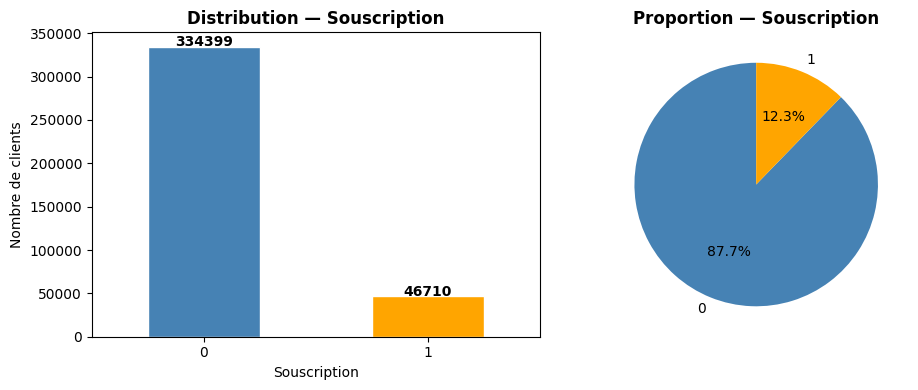

In [8]:
# Déséquilibre de la variable cible
print("Distribution de la variable cible :")
print(df["Souscription"].value_counts())
print()
print(df["Souscription"].value_counts(normalize=True).round(3))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

df["Souscription"].value_counts().plot(
    kind="bar", ax=ax1, color=["steelblue","orange"],
    rot=0, edgecolor="white"
)
ax1.set_title("Distribution — Souscription", fontweight="bold")
ax1.set_xlabel("Souscription")
ax1.set_ylabel("Nombre de clients")
for i, v in enumerate(df["Souscription"].value_counts()):
    ax1.text(i, v + 500, str(v), ha="center", fontweight="bold")

df["Souscription"].value_counts().plot(
    kind="pie", ax=ax2, autopct="%1.1f%%",
    colors=["steelblue","orange"], startangle=90
)
ax2.set_title("Proportion — Souscription", fontweight="bold")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()


Classes deséquilibrées, on evalue avec Recall, Précision, F1 et Roc-Auc et on utilise class_weight

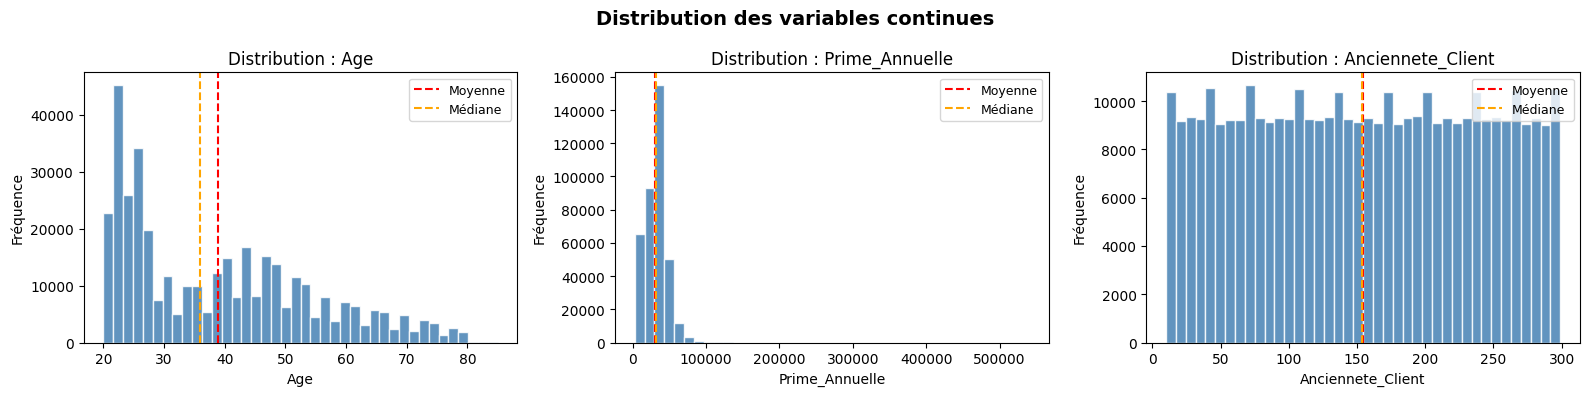

In [9]:
# Distribution des variables continues
n_cols = 3
n_rows = (len(cols_continues) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_continues):
    axes[i].hist(df[col], bins=40, color="steelblue",
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Distribution : {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--",
                    linewidth=1.5, label="Moyenne")
    axes[i].axvline(df[col].median(), color="orange", linestyle="--",
                    linewidth=1.5, label="Médiane")
    axes[i].legend(fontsize=9)

for j in range(len(cols_continues), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables continues",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Distribution asymetriques pour Prime_annuelle, on utilse RobustScaler() pour la standardisation, les 2 autres, on utilse StandardScaler()

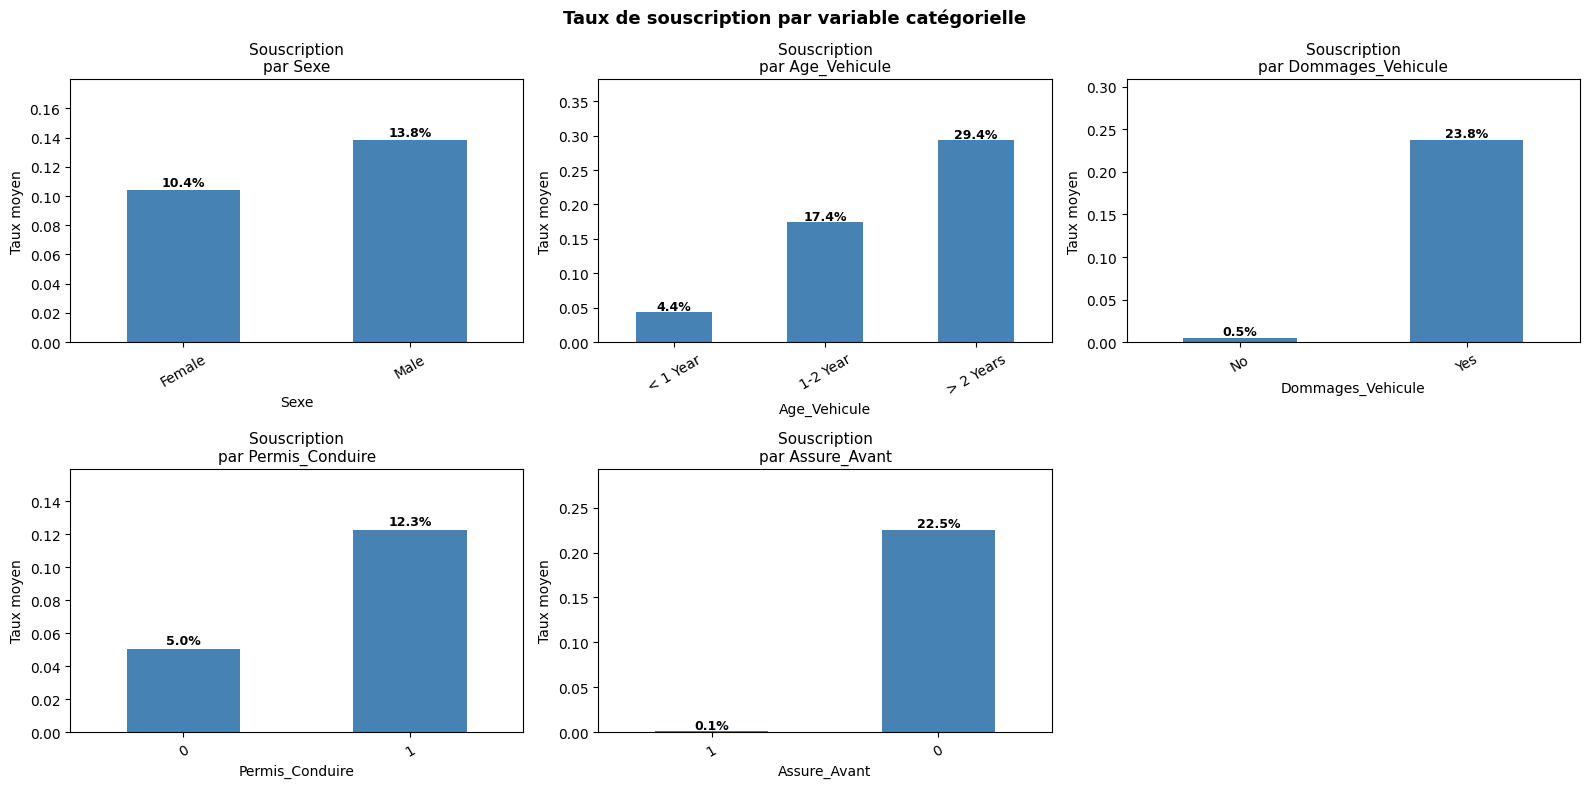

In [10]:
# Taux de souscription par variable catégorielle
n_cols = 3
n_rows = (len(cols_categorielles) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_categorielles):
    taux = df.groupby(col)["Souscription"].mean().sort_values()
    taux.plot(kind="bar", ax=axes[i], color="steelblue", rot=30)
    axes[i].set_title(f"Souscription\npar {col}", fontsize=11)
    axes[i].set_ylabel("Taux moyen")
    axes[i].set_ylim(0, taux.max() * 1.3)
    for j, v in enumerate(taux.values):
        axes[i].text(j, v + 0.003, f"{v:.1%}",
                     ha="center", fontsize=9, fontweight="bold")

for j in range(len(cols_categorielles), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taux de souscription par variable catégorielle",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Les clients qui ont un permis de conduire, qui ne sont pas assurés actuellement et dont leurs vehicules presentent des dommages sont plus susceptibles de souscrire.
Plus le vehicule est age, plus plus l'individu est susceptible de souscrire
Le sexe n'est pas un bon indicateur de souscription

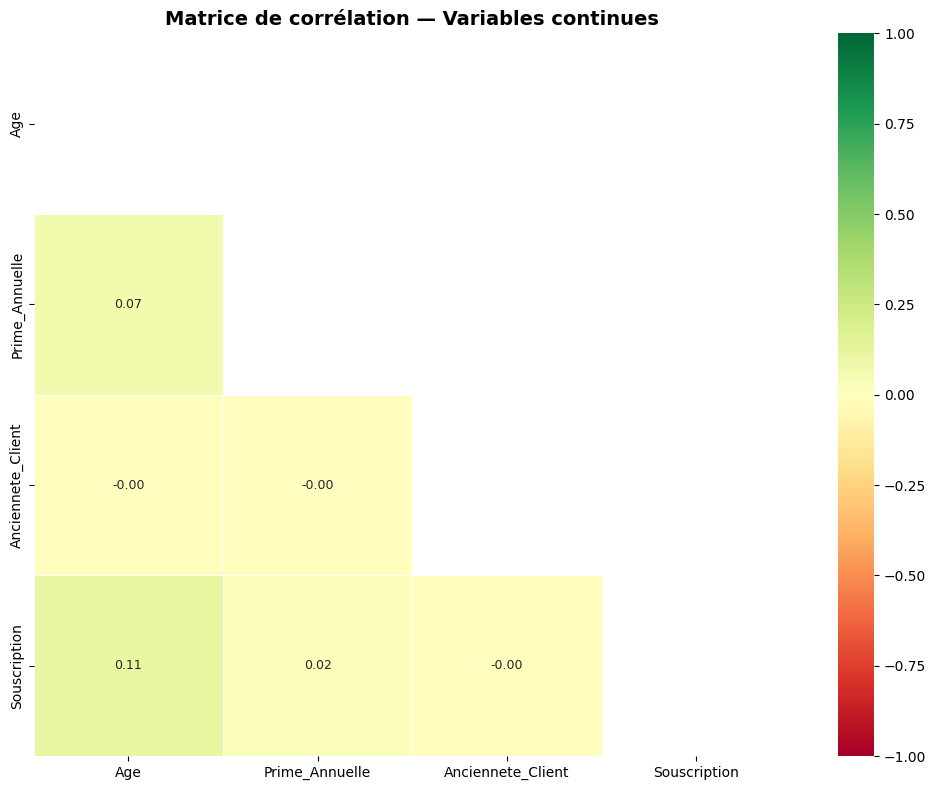


Corrélations avec Souscription :
Age                  0.111
Prime_Annuelle       0.023
Anciennete_Client   -0.001
Name: Souscription, dtype: float64


In [11]:
# Matrice de corrélation — variables continues uniquement
cols_pour_corr = cols_continues + ["Souscription"]
df_corr = df[cols_pour_corr].copy()

plt.figure(figsize=(10, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 9})
plt.title("Matrice de corrélation — Variables continues",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrélations avec Souscription :")
print(corr["Souscription"]
      .drop("Souscription")
      .sort_values(key=abs, ascending=False)
      .round(3))

On remarque une corrélation faible des variables continues avec la cible

### Preprocessing

In [12]:
# Suppression ID
df.drop("ID_Client", axis=1, inplace=True)

# Encodage variables catégorielles texte
df["Sexe"] = df["Sexe"].map({"Male": 0, "Female": 1})

df["Dommages_Vehicule"] = df["Dommages_Vehicule"].map({"No": 0, "Yes": 1})

df["Age_Vehicule"] = df["Age_Vehicule"].map({
    "< 1 Year": 0,
    "1-2 Year" : 1,
    "> 2 Years": 2
})

print(df.dtypes)

Sexe                   int64
Age                    int64
Permis_Conduire        int64
Code_Region          float64
Assure_Avant           int64
Age_Vehicule           int64
Dommages_Vehicule      int64
Prime_Annuelle       float64
Canal_Vente          float64
Anciennete_Client      int64
Souscription           int64
dtype: object


In [13]:
df.head()

,Sexe,Age,Permis_Conduire,Code_Region,Assure_Avant,Age_Vehicule,Dommages_Vehicule,Prime_Annuelle,Canal_Vente,Anciennete_Client,Souscription
0,0,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,0,76,1,3.0,0,1,0,33536.0,26.0,183,0
2,0,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,0,21,1,11.0,1,0,0,28619.0,152.0,203,0
4,1,29,1,41.0,1,0,0,27496.0,152.0,39,0


### Séparation X/y et split train-test

In [14]:
X = df.drop("Souscription", axis=1)
y = df["Souscription"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nDéséquilibre train :")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDéséquilibre test :")
print(y_test.value_counts(normalize=True).round(3))

Train : (304887, 10)
Test  : (76222, 10)

Déséquilibre train :
Souscription
0    0.877
1    0.123
Name: proportion, dtype: float64

Déséquilibre test :
Souscription
0    0.877
1    0.123
Name: proportion, dtype: float64


### Pipeline — Scaling et Modèle

In [15]:
# Variables asymétriques → RobustScaler
cols_robust   = ["Prime_Annuelle"]

# Variables symétriques → StandardScaler
cols_standard = ["Age", "Anciennete_Client"]

preprocessor = ColumnTransformer(transformers=[
    ("robust",   RobustScaler(),   cols_robust),
    ("standard", StandardScaler(), cols_standard)
], remainder="passthrough")

# Pipeline — évite tout data leakage
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("modele", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Entraînement sur X_train brut
pipeline.fit(X_train, y_train)
print("Pipeline entraîné ")

Pipeline entraîné 


### Prédictions

In [16]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

### Évaluation

In [17]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("\nReport :\n", classification_report(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_proba)) 

Accuracy : 0.6402219831544699

Confusion Matrix :
 [[39678 27202]
 [  221  9121]]

Report :
               precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.98      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222

ROC AUC : 0.8343613282710484


Interprétation
- AUC-ROC : 0.834; le modèle classe bien
- Recall    : 0.98; on détecte 98% des souscripteurs
- Precision : 0.25; sur 100 contactés, 25 souscrivent

### Seuil optimal

Seuil optimal : 0.67
F1 maximum    : 0.435


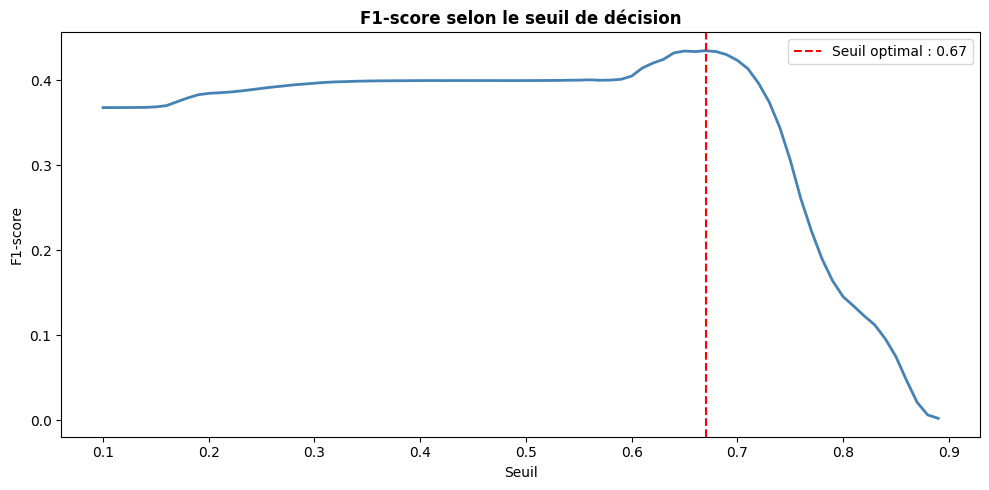


Seuil défaut (0.50)
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.98      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222

Seuil optimal (0.67)
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     66880
           1       0.31      0.74      0.43      9342

    accuracy                           0.76     76222
   macro avg       0.63      0.75      0.64     76222
weighted avg       0.88      0.76      0.80     76222



In [18]:
seuils    = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_proba >= s).astype(int))
             for s in seuils]

seuil_optimal = seuils[np.argmax(f1_scores)]
print(f"Seuil optimal : {seuil_optimal:.2f}")
print(f"F1 maximum    : {max(f1_scores):.3f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(seuils, f1_scores, color="steelblue", linewidth=2)
plt.axvline(seuil_optimal, color="red", linestyle="--",
            label=f"Seuil optimal : {seuil_optimal:.2f}")
plt.xlabel("Seuil")
plt.ylabel("F1-score")
plt.title("F1-score selon le seuil de décision", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Réévaluer avec seuil optimal
y_pred_optimal = (y_proba >= seuil_optimal).astype(int)
print("\nSeuil défaut (0.50)")
print(classification_report(y_test, y_pred))
print(f"Seuil optimal ({seuil_optimal:.2f})")
print(classification_report(y_test, y_pred_optimal))

Avec le seuil optimal 0.67, nous avons un meilleur f1-score et une meilleure precision. Cependant, le recall a diminue. Ainsi le choix du seuil ideal depend des objectifs assignes

### Validation croisée

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline, X, y,
    cv=cv,
    scoring="roc_auc"
)

print("AUC par fold :")
for i, score in enumerate(scores):
    print(f"  Fold {i+1} : {score:.4f}")

print(f"\nAUC moyen  : {scores.mean():.4f}")
print(f"Écart-type : {scores.std():.4f}")

if scores.std() < 0.03:
    print("\nModèle stable — écart-type faible ")
else:
    print("\nModèle instable — écart-type élevé ")

AUC par fold :
  Fold 1 : 0.8307
  Fold 2 : 0.8316
  Fold 3 : 0.8310
  Fold 4 : 0.8345
  Fold 5 : 0.8327

AUC moyen  : 0.8321
Écart-type : 0.0014

Modèle stable — écart-type faible 


### Feature Importance — Coefficients

Coefficients du modèle :
          Feature  Coefficient  Abs_Coef
     Assure_Avant    -4.101218  4.101218
Dommages_Vehicule     1.999646  1.999646
  Permis_Conduire     1.264719  1.264719
     Age_Vehicule     0.759662  0.759662
              Age    -0.318220  0.318220
             Sexe    -0.107919  0.107919
   Prime_Annuelle     0.015011  0.015011
Anciennete_Client    -0.004810  0.004810
      Canal_Vente    -0.002626  0.002626
      Code_Region    -0.000263  0.000263


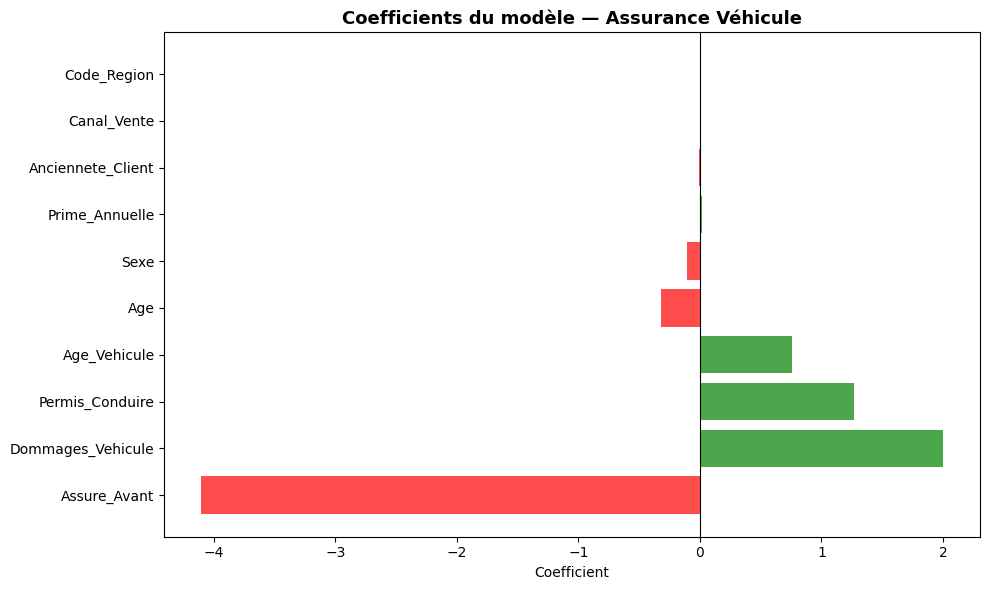

In [20]:
feature_names = (
    cols_robust +
    cols_standard +
    list(X_train.drop(cols_robust + cols_standard, axis=1).columns)
)

coefficients = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": pipeline.named_steps["modele"].coef_[0],
    "Abs_Coef"   : np.abs(pipeline.named_steps["modele"].coef_[0])
}).sort_values("Abs_Coef", ascending=False)

print("Coefficients du modèle :")
print(coefficients.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
colors = ["green" if c > 0 else "red"
          for c in coefficients["Coefficient"]]
plt.barh(coefficients["Feature"],
         coefficients["Coefficient"],
         color=colors, alpha=0.7)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coefficients du modèle — Assurance Véhicule",
          fontsize=13, fontweight="bold")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

On remarque que Assurance_Avant, Dommages_Vehicule, Permis_Conduire et Age_vehicules sont les variables predictives, sexe et Age peu predictive; Code_Region et Canal_Vente n'apportent rien a la prediction.

Nombre optimal de features : 9

Features sélectionnées :
  ✅ Prime_Annuelle
  ✅ Age
  ✅ Anciennete_Client
  ✅ Sexe
  ✅ Permis_Conduire
  ✅ Assure_Avant
  ✅ Age_Vehicule
  ✅ Dommages_Vehicule
  ✅ Canal_Vente

Features supprimées :
  ❌ Code_Region


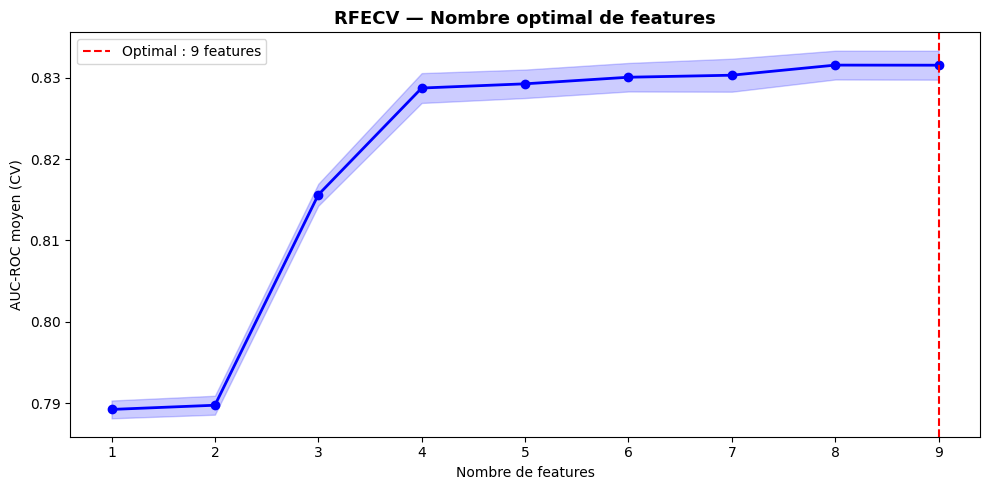

In [21]:

X_train_scaled = pipeline.named_steps['preprocessing'].transform(X_train)
X_test_scaled  = pipeline.named_steps['preprocessing'].transform(X_test)

model_rfecv = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=model_rfecv,
    cv=cv,
    scoring='roc_auc',
    min_features_to_select=2,
    n_jobs=-1 
)

rfecv.fit(X_train_scaled, y_train)

print(f"Nombre optimal de features : {rfecv.n_features_}")

features_selectionnees = [feature_names[i]
                          for i in range(len(feature_names))
                          if rfecv.support_[i]]
features_supprimees    = [feature_names[i]
                          for i in range(len(feature_names))
                          if not rfecv.support_[i]]

print("\nFeatures sélectionnées :")
for f in features_selectionnees:
    print(f"  ✅ {f}")
print("\nFeatures supprimées :")
for f in features_supprimees:
    print(f"  ❌ {f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    'bo-', linewidth=2, markersize=6
)
plt.fill_between(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
    rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'],
    alpha=0.2, color='blue'
)
plt.axvline(rfecv.n_features_, color='red', linestyle='--',
            label=f'Optimal : {rfecv.n_features_} features')
plt.xlabel("Nombre de features")
plt.ylabel("AUC-ROC moyen (CV)")
plt.title("RFECV — Nombre optimal de features",
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

La variable "Canal_Vente" gardée est un peu surprenante, car elle faisait parti des variables prédictives quasi-nulles, Par contre Code_region a ete confirmée comme variable a supprimée 

### GridSearchCV

In [22]:
# Sélection des 9 features
X_train_selected = X_train_scaled[:, rfecv.support_]
X_test_selected  = X_test_scaled[:, rfecv.support_]

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_selected, y_train)

print(f"Meilleur C   : {grid_search.best_params_['C']}")
print(f"Meilleur AUC : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
print("\nAUC par valeur de C :")
print(results[['param_C', 'mean_test_score',
               'std_test_score']].to_string(index=False))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleur C   : 5
Meilleur AUC : 0.8316

AUC par valeur de C :
 param_C  mean_test_score  std_test_score
   0.001         0.830637        0.001776
   0.010         0.831486        0.001768
   0.100         0.831552        0.001771
   0.500         0.831547        0.001772
   1.000         0.831553        0.001770
   5.000         0.831554        0.001770
  10.000         0.831554        0.001773
 100.000         0.831549        0.001783


### Modèle final

In [23]:
model_final   = grid_search.best_estimator_

y_pred_final  = model_final.predict(X_test_selected)
y_proba_final = model_final.predict_proba(X_test_selected)[:, 1]

# Seuil optimal final
seuils    = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_proba_final >= s).astype(int))
             for s in seuils]
seuil_final = seuils[np.argmax(f1_scores)]

y_pred_seuil = (y_proba_final >= seuil_final).astype(int)

# Comparaison
auc_final = roc_auc_score(y_test, y_proba_final)


print(f"{'':>20} Baseline   Final")
print(f"{'AUC-ROC':>20}    0.834      {auc_final:.4f}")
print(f"{'Features':>20}    10         {rfecv.n_features_}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_seuil))

                     Baseline   Final
             AUC-ROC    0.834      0.8344
            Features    10         9

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     66880
           1       0.31      0.74      0.43      9342

    accuracy                           0.76     76222
   macro avg       0.63      0.75      0.64     76222
weighted avg       0.88      0.76      0.80     76222



On remarque notre modèle depart et celui optimisé ont un AUC-ROC quasiéq uivalent, alors on conclu que ce modèle est insensible a l'hyperpramétre C

### Sauvegarde du modèle

In [24]:
joblib.dump(pipeline,            "pipeline_assurance.pkl")
joblib.dump(model_final,         "model_assurance_final.pkl")
joblib.dump(rfecv.support_,      "features_support_assurance.pkl")
joblib.dump(seuil_final,         "seuil_assurance.pkl")

print("Modèle sauvegardé :")

Modèle sauvegardé :
